In [ ]:
import pandas as pd
import numpy as np

import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fake reviews dataset.csv to fake reviews dataset (3).csv


In [ ]:
df = pd.read_csv("fake reviews dataset.csv")

print(df.head())
print(df['label'].value_counts())

             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  
label
CG    20216
OR    20216
Name: count, dtype: int64


In [ ]:
df['label'] = df['label'].map({
    'CG': 0,   # Fake
    'OR': 1    # Genuine
})

In [ ]:
print(df['label'].value_counts())

label
0    20216
1    20216
Name: count, dtype: int64


In [ ]:
#preprocessig of the text
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()

    # Keep important words like 'not' and 'no'
    words = [word for word in words if word not in stop_words or word in ['not', 'no']]

    return " ".join(words)

df['cleaned'] = df['text_'].apply(clean_text)

In [ ]:
df = df[['cleaned', 'label']].dropna()   #handles missing values/ cleaning data

In [ ]:
#vectorization(TF-IDF)
vectorizer = TfidfVectorizer(max_features=7000, ngram_range=(1,2))

X = vectorizer.fit_transform(df['cleaned'])
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8751081983430197

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      4016
           1       0.87      0.89      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087



In [ ]:
def predict_review(review):
    cleaned = clean_text(review)
    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0]

    fake_prob = probability[1]
    real_prob = probability[0]

    print("\n Review:", review)

    if prediction == 1:
        print(" Prediction:Genuine Review ✅")
        print(f" Confidence: {fake_prob:.2f}")
    else:
        print(" Prediction: Fake Review ❌")
        print(f" Confidence: {real_prob:.2f}")

    print(f" Fake Probability: {fake_prob:.2f} | Real Probability: {real_prob:.2f}")

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4016
           1       0.87      0.89      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087



In [ ]:
predict_review("This is the best product ever!!! Highly recommend!!! Must buy!!!")

predict_review("Worst product ever waste of money totally fake quality")

predict_review("Do not buy this item very bad experience and poor quality")

predict_review("Amazing product works perfectly I love it")



 Review: This is the best product ever!!! Highly recommend!!! Must buy!!!
 Prediction: Fake Review ❌
 Confidence: 0.59
 Fake Probability: 0.41 | Real Probability: 0.59

 Review: Worst product ever waste of money totally fake quality
 Prediction:Genuine Review ✅
 Confidence: 0.87
 Fake Probability: 0.87 | Real Probability: 0.13

 Review: Do not buy this item very bad experience and poor quality
 Prediction:Genuine Review ✅
 Confidence: 0.73
 Fake Probability: 0.73 | Real Probability: 0.27

 Review: Amazing product works perfectly I love it
 Prediction: Fake Review ❌
 Confidence: 0.69
 Fake Probability: 0.31 | Real Probability: 0.69


In [ ]:
#more testing
predict_review("The product is good but the packaging was bad")

predict_review("I like the product but it is a bit expensive")

predict_review("Quality is okay not too good not too bad")

predict_review("It works fine but sometimes it has issues")

predict_review("Decent product but could be improved")


 Review: The product is good but the packaging was bad
 Prediction: Fake Review ❌
 Confidence: 0.50
 Fake Probability: 0.50 | Real Probability: 0.50

 Review: I like the product but it is a bit expensive
 Prediction: Fake Review ❌
 Confidence: 0.61
 Fake Probability: 0.39 | Real Probability: 0.61

 Review: Quality is okay not too good not too bad
 Prediction: Fake Review ❌
 Confidence: 0.76
 Fake Probability: 0.24 | Real Probability: 0.76

 Review: It works fine but sometimes it has issues
 Prediction:Genuine Review ✅
 Confidence: 0.72
 Fake Probability: 0.72 | Real Probability: 0.28

 Review: Decent product but could be improved
 Prediction:Genuine Review ✅
 Confidence: 0.79
 Fake Probability: 0.79 | Real Probability: 0.21


In [ ]:
predict_review("Good product")

predict_review("Bad quality")

predict_review("Excellent")

predict_review("Waste of money")

predict_review("Not good")


 Review: Good product
 Prediction: Fake Review ❌
 Confidence: 0.61
 Fake Probability: 0.39 | Real Probability: 0.61

 Review: Bad quality
 Prediction:Genuine Review ✅
 Confidence: 0.55
 Fake Probability: 0.55 | Real Probability: 0.45

 Review: Excellent
 Prediction:Genuine Review ✅
 Confidence: 0.50
 Fake Probability: 0.50 | Real Probability: 0.50

 Review: Waste of money
 Prediction:Genuine Review ✅
 Confidence: 0.77
 Fake Probability: 0.77 | Real Probability: 0.23

 Review: Not good
 Prediction: Fake Review ❌
 Confidence: 0.61
 Fake Probability: 0.39 | Real Probability: 0.61


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
ann_model = Sequential()

ann_model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
ann_model.fit(
    X_train.toarray(),
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test.toarray(), y_test)
)

Epoch 1/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8727 - loss: 0.2917 - val_accuracy: 0.9081 - val_loss: 0.2215
Epoch 2/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9319 - loss: 0.1671 - val_accuracy: 0.9058 - val_loss: 0.2274
Epoch 3/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9537 - loss: 0.1158 - val_accuracy: 0.9064 - val_loss: 0.2428
Epoch 4/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9777 - loss: 0.0615 - val_accuracy: 0.9037 - val_loss: 0.3197
Epoch 5/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9933 - loss: 0.0216 - val_accuracy: 0.9023 - val_loss: 0.4004


In [ ]:
loss, accuracy = ann_model.evaluate(X_test.toarray(), y_test)
print("ANN Accuracy:", accuracy)

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9023 - loss: 0.4004
ANN Accuracy: 0.9023123383522034


In [ ]:
#for LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['cleaned'])

X_seq = tokenizer.texts_to_sequences(df['cleaned'])
X_pad = pad_sequences(X_seq, maxlen=100)
y = df['label']

In [ ]:
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_pad, y, test_size=0.2, random_state=42
)

In [ ]:
lstm_model = Sequential()

lstm_model.add(Embedding(5000, 64, input_length=100))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=3,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_lstm)
)

Epoch 1/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 50s 91ms/step - accuracy: 0.8484 - loss: 0.3338 - val_accuracy: 0.8977 - val_loss: 0.2459
Epoch 2/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 46s 91ms/step - accuracy: 0.9157 - loss: 0.2058 - val_accuracy: 0.9050 - val_loss: 0.2301
Epoch 3/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.9324 - loss: 0.1668 - val_accuracy: 0.8958 - val_loss: 0.2708


In [ ]:
loss, accuracy = lstm_model.evaluate(X_test_lstm, y_test_lstm)
print("LSTM Accuracy:", accuracy)

253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8958 - loss: 0.2708
LSTM Accuracy: 0.8957586288452148


In [ ]:
#for CNN
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_model = Sequential()

cnn_model.add(Embedding(5000, 64, input_length=100))
cnn_model.add(Conv1D(64, 5, activation='relu'))
cnn_model.add(GlobalMaxPooling1D())
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=3,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_lstm)
)

loss, accuracy = cnn_model.evaluate(X_test_lstm, y_test_lstm)
print("CNN Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.8361 - loss: 0.3833 - val_accuracy: 0.8851 - val_loss: 0.2773
Epoch 2/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9144 - loss: 0.2140 - val_accuracy: 0.8949 - val_loss: 0.2582
Epoch 3/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.9466 - loss: 0.1444 - val_accuracy: 0.8913 - val_loss: 0.2788
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8913 - loss: 0.2788
CNN Accuracy: 0.8913070559501648


In [ ]:
from textblob import TextBlob

In [ ]:
def get_sentiment(review):
    analysis = TextBlob(review)
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive 😊"
    elif polarity < 0:
        return "Negative 😞"
    else:
        return "Neutral 😐"

In [ ]:
def final_prediction(review):
    cleaned = clean_text(review)
    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]
    sentiment = get_sentiment(review)

    print("\n📝 Review:", review)

    if prediction == 0:
        print("🔍 Fake Review ❌")
    else:
        print("🔍 Genuine Review ✅")

    print("😊 Sentiment:", sentiment)

In [ ]:
def predict_cnn(review):
    cleaned = clean_text(review)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=100)

    prediction = cnn_model.predict(pad)[0][0]

    print("\n📝 Review:", review)

    if prediction > 0.5:
        print("🔍 Prediction: Genuine Review ✅")
        print(f"📊 Confidence: {prediction:.2f}")
    else:
        print("🔍 Prediction: Fake Review ❌")
        print(f"📊 Confidence: {1 - prediction:.2f}")

In [ ]:
predict_cnn("Worst product ever waste of money totally fake quality")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step

📝 Review: Worst product ever waste of money totally fake quality
🔍 Prediction: Genuine Review ✅
📊 Confidence: 1.00


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Naive Bayes
print("\nNaive Bayes:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Naive Bayes:
Precision: 0.86729061675066
Recall: 0.8877425693932695
F1 Score: 0.8773974265598447


In [ ]:
from sklearn.metrics import f1_score

# Naive Bayes
nb_f1 = f1_score(y_test, y_pred)

# ANN
ann_preds = (ann_model.predict(X_test.toarray()) > 0.5).astype("int32")
ann_f1 = f1_score(y_test, ann_preds)

# LSTM
lstm_preds = (lstm_model.predict(X_test_lstm) > 0.5).astype("int32")
lstm_f1 = f1_score(y_test_lstm, lstm_preds)

# CNN
cnn_preds = (cnn_model.predict(X_test_lstm) > 0.5).astype("int32")
cnn_f1 = f1_score(y_test_lstm, cnn_preds)

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
253/253 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
nb_acc = accuracy_score(y_test, y_pred)

ann_acc = ann_model.evaluate(X_test.toarray(), y_test, verbose=0)[1]

lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)[1]

cnn_acc = cnn_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)[1]

print("\n📊 MODEL COMPARISON:")
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")
print(f"ANN Accuracy: {ann_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")
print(f"CNN Accuracy: {cnn_acc:.4f}")


📊 MODEL COMPARISON:
Naive Bayes Accuracy: 0.8751
ANN Accuracy: 0.9023
LSTM Accuracy: 0.8958
CNN Accuracy: 0.8913


In [ ]:
print("\nFINAL COMPARISON:")
print("NB F1:", f1_score(y_test, y_pred))
print("ANN F1:", f1_score(y_test, ann_preds))
print("LSTM F1:", f1_score(y_test_lstm, lstm_preds))
print("CNN F1:", f1_score(y_test_lstm, cnn_preds))


FINAL COMPARISON:
NB F1: 0.8773974265598447
ANN F1: 0.9030674846625767
LSTM F1: 0.9011607456911713
CNN F1: 0.895169946332737


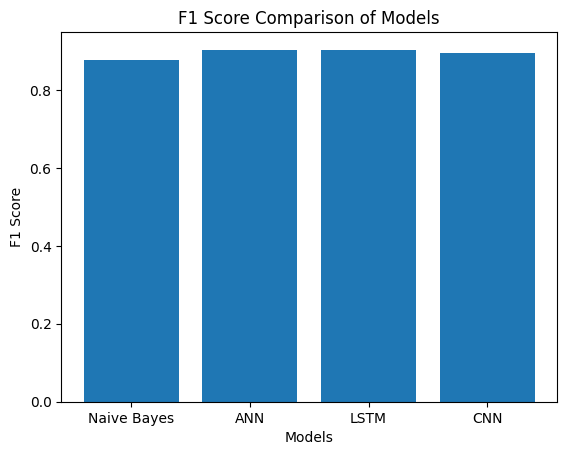

In [ ]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'ANN', 'LSTM', 'CNN']
f1_scores = [nb_f1, ann_f1, lstm_f1, cnn_f1]

plt.figure()
plt.bar(models, f1_scores)

plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Models")

plt.show()

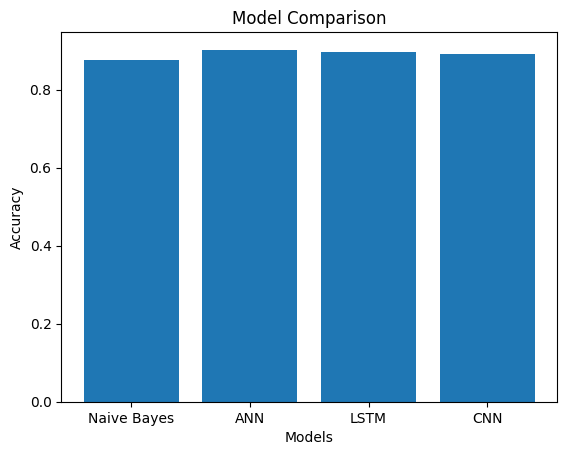

In [ ]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'ANN', 'LSTM', 'CNN']
accuracies = [nb_acc, ann_acc, lstm_acc, cnn_acc]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()